In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
from model.bulkformer import BulkFormer, model_params

device = "cuda" if torch.cuda.is_available() else "cpu"
device


/home/walt/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

In [2]:
ckpt_path = "bulkformer_checkpoints/best_model.pt"   # or whichever epoch you want
state_dict = torch.load(ckpt_path, map_location="cpu")

import json

with open("checkpoints/config.json", "r") as f:
    cfg = json.load(f)

cfg

esm2_data = torch.load("./data/embeddings/esm2_t6_8M_UR50D_gene_embeddings.pt")
gene_emb = esm2_data["embeddings"].float()

edge_index = torch.load("./graph/edge_index_top20.pt").long()



In [3]:
import pandas as pd
from pathlib import Path

# ----------------------------
# Paths
# ----------------------------
data_dir = Path("data/tcga")
raw_dir = data_dir / "raw"
manifest_file = data_dir / "gdc_manifest.2025-11-16.123311.txt"
sample_sheet_file = data_dir / "gdc_sample_sheet.2025-11-16.tsv"

# ----------------------------
# Load manifest
# ----------------------------
manifest_df = pd.read_csv(manifest_file, sep="\t")
print(f"Manifest contains {len(manifest_df)} files")

# Manifest columns: id, filename, md5, size, state
# We need only id + filename
count_files = {}

for _, row in manifest_df.iterrows():
    file_id = row["id"]
    filename = row["filename"]

    file_path = raw_dir / file_id / filename

    if file_path.exists():
        count_files[file_id] = file_path
    else:
        print(f"Warning: Missing file: {file_id}")

print(f"\nFound {len(count_files)} of {len(manifest_df)} manifest entries")

# ----------------------------
# Load sample sheet (metadata)
# ----------------------------
sample_sheet_df = pd.read_csv(sample_sheet_file, sep="\t")
metadata = sample_sheet_df[["File ID", "Project ID", "Tissue Type"]].copy()
metadata.columns = ["file_id", "project_id", "tissue_type"]

print(f"Metadata loaded for {len(metadata)} samples")

# ----------------------------
# Merge file paths + metadata
# ----------------------------
file_mapping = pd.DataFrame(
    list(count_files.items()), 
    columns=["file_id", "file_path"]
)

file_mapping = file_mapping.merge(metadata, on="file_id", how="left")

# Save mapping
file_mapping.to_csv(data_dir / "file_mapping.csv", index=False)
metadata.to_csv(data_dir / "metadata.csv", index=False)

print("\nSaved file_mapping.csv and metadata.csv")
print(file_mapping.head())

# ----------------------------
# Load one count file to preview
# ----------------------------
if len(file_mapping):
    example_file = file_mapping.iloc[0]["file_path"]
    print(f"\nReading sample counts from:\n{example_file}\n")
    df_example = pd.read_csv(example_file, sep="\t", comment="#")
    # print(df_example.head())

df_example.head()


Manifest contains 3481 files

Found 3481 of 3481 manifest entries
Metadata loaded for 3481 samples

Saved file_mapping.csv and metadata.csv
                                file_id  \
0  9dc09c86-c728-4bd9-b2b6-2d9962dad662   
1  95668f0b-130d-44d4-94c0-ba7a4e7798e6   
2  461fda5d-d6e6-4354-b035-c302cc43b03f   
3  30ff778c-844b-4140-9025-7ab1938f10a9   
4  427a04c9-9b48-49de-8a47-2adc4e1dd32a   

                                           file_path project_id tissue_type  
0  data/tcga/raw/9dc09c86-c728-4bd9-b2b6-2d9962da...  TCGA-BRCA       Tumor  
1  data/tcga/raw/95668f0b-130d-44d4-94c0-ba7a4e77...  TCGA-BRCA       Tumor  
2  data/tcga/raw/461fda5d-d6e6-4354-b035-c302cc43...  TCGA-BRCA       Tumor  
3  data/tcga/raw/30ff778c-844b-4140-9025-7ab1938f...  TCGA-BRCA       Tumor  
4  data/tcga/raw/427a04c9-9b48-49de-8a47-2adc4e1d...  TCGA-BRCA       Tumor  

Reading sample counts from:
data/tcga/raw/9dc09c86-c728-4bd9-b2b6-2d9962dad662/d1f1743c-5fd9-4ae8-90c2-8c3e2d475d1b.rna_seq.augmente

,gene_id,gene_name,gene_type,unstranded,stranded_first,stranded_second,tpm_unstranded,fpkm_unstranded,fpkm_uq_unstranded
0,N_unmapped,NaN,NaN,4313871,4313871,4313871,NaN,NaN,NaN
1,N_multimapping,NaN,NaN,9111078,9111078,9111078,NaN,NaN,NaN
2,N_noFeature,NaN,NaN,5923368,39711848,39910067,NaN,NaN,NaN
3,N_ambiguous,NaN,NaN,7420053,1883578,1872503,NaN,NaN,NaN
4,ENSG00000000003.15,TSPAN6,protein_coding,1984,953,1031,16.5243,7.4706,7.9838


In [4]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# ----------------------------
# Paths
# ----------------------------
data_dir = Path("data/tcga")
raw_dir = data_dir / "raw"
manifest_file = data_dir / "gdc_manifest.2025-11-16.123311.txt"
sample_sheet_file = data_dir / "gdc_sample_sheet.2025-11-16.tsv"

matrix_parquet = data_dir / "tcga_unstranded_matrix.parquet"
metadata_parquet = data_dir / "tcga_metadata.parquet"
file_mapping_csv = data_dir / "file_mapping.csv"

# -----------------------------------------------------
# 3️⃣ Load safe gene list + canonical gene order (cheap; keep)
# -----------------------------------------------------
safe_path = Path("./data/archs4/processed_short_proteins/test_gene_order_short.csv")
safe_genes_df = pd.read_csv(safe_path)
canonical_order = safe_genes_df["gene_symbol"].tolist()
protein_coding_genes = set(canonical_order)
print(f"Loaded {len(canonical_order)} canonical protein-coding genes")

# -----------------------------------------------------
# Fast-path: load precomputed outputs if they exist
# -----------------------------------------------------
if matrix_parquet.exists() and metadata_parquet.exists():
    print("Detected existing processed outputs. Loading...")
    X = pd.read_parquet(matrix_parquet)
    file_mapping = pd.read_parquet(metadata_parquet)
    sample_ids = X.index.tolist()
    print(f"Loaded matrix shape: {X.shape}")
    print(f"Loaded metadata rows: {len(file_mapping)}")
else:
    # -----------------------------------------------------
    # 1️⃣ Load manifest
    # -----------------------------------------------------
    manifest_df = pd.read_csv(manifest_file, sep="\t")
    print(f"Manifest contains {len(manifest_df)} files")

    count_files = {}
    for _, row in manifest_df.iterrows():
        file_id = row["id"]
        filename = row["filename"]
        file_path = raw_dir / file_id / filename
        if file_path.exists():
            count_files[file_id] = file_path
        else:
            print(f"Warning: Missing file: {file_id}")
    print(f"Found {len(count_files)} files")

    # -----------------------------------------------------
    # 2️⃣ Load sample sheet metadata
    # -----------------------------------------------------
    sample_sheet_df = pd.read_csv(sample_sheet_file, sep="\t")
    metadata = sample_sheet_df[["File ID", "Project ID", "Tissue Type"]].copy()
    metadata.columns = ["file_id", "project_id", "tissue_type"]
    print(f"Metadata loaded for {len(metadata)} samples")

    file_mapping = (
        pd.DataFrame(list(count_files.items()), columns=["file_id", "file_path"])
          .merge(metadata, on="file_id", how="left")
    )
    # Ensure paths are strings for Arrow/Parquet compatibility
    file_mapping["file_path"] = file_mapping["file_path"].astype(str)
    file_mapping.to_csv(file_mapping_csv, index=False)

    print("Saved file_mapping.csv")
    print(file_mapping.head())

    # -----------------------------------------------------
    # Loader
    # -----------------------------------------------------
    def load_tcga_counts(path, protein_gene_symbols, canonical_order):
        df = pd.read_csv(path, sep="\t", comment="#")
        df = df[df["gene_name"].notna()]
        df = df[df["gene_type"] == "protein_coding"]
        df = df[df["gene_name"].isin(protein_gene_symbols)]
        df = df.sort_values("unstranded", ascending=False).drop_duplicates("gene_name")
        df = df.set_index("gene_name").reindex(canonical_order)
        df["unstranded"] = df["unstranded"].fillna(0)
        return df["unstranded"]

    # -----------------------------------------------------
    # 5️⃣ Process samples
    # -----------------------------------------------------
    all_vectors = []
    sample_ids = []
    print("Processing TCGA samples...")
    for _, row in tqdm(file_mapping.iterrows(), total=len(file_mapping)):
        vec = load_tcga_counts(row["file_path"], protein_coding_genes, canonical_order)
        all_vectors.append(vec.values)
        sample_ids.append(row["file_id"])

    X = pd.DataFrame(all_vectors, index=sample_ids, columns=canonical_order)
    print("Final matrix shape:", X.shape)

    # -----------------------------------------------------
    # 6️⃣ Save outputs
    # -----------------------------------------------------
    X.to_parquet(matrix_parquet, index=True)
    file_mapping.to_parquet(metadata_parquet, index=False)
    print("Saved:")
    print(f" - {matrix_parquet.name}")
    print(f" - {metadata_parquet.name}")



Loaded 19357 canonical protein-coding genes
Manifest contains 3481 files
Found 3481 files
Metadata loaded for 3481 samples
Saved file_mapping.csv
                                file_id  \
0  9dc09c86-c728-4bd9-b2b6-2d9962dad662   
1  95668f0b-130d-44d4-94c0-ba7a4e7798e6   
2  461fda5d-d6e6-4354-b035-c302cc43b03f   
3  30ff778c-844b-4140-9025-7ab1938f10a9   
4  427a04c9-9b48-49de-8a47-2adc4e1dd32a   

                                           file_path project_id tissue_type  
0  data/tcga/raw/9dc09c86-c728-4bd9-b2b6-2d9962da...  TCGA-BRCA       Tumor  
1  data/tcga/raw/95668f0b-130d-44d4-94c0-ba7a4e77...  TCGA-BRCA       Tumor  
2  data/tcga/raw/461fda5d-d6e6-4354-b035-c302cc43...  TCGA-BRCA       Tumor  
3  data/tcga/raw/30ff778c-844b-4140-9025-7ab1938f...  TCGA-BRCA       Tumor  
4  data/tcga/raw/427a04c9-9b48-49de-8a47-2adc4e1d...  TCGA-BRCA       Tumor  
Processing TCGA samples...


100%|██████████| 3481/3481 [05:53<00:00,  9.85it/s]


Final matrix shape: (3481, 19357)


ArrowInvalid: ("Could not convert PosixPath('data/tcga/raw/9dc09c86-c728-4bd9-b2b6-2d9962dad662/d1f1743c-5fd9-4ae8-90c2-8c3e2d475d1b.rna_seq.augmented_star_gene_counts.tsv') with type PosixPath: did not recognize Python value type when inferring an Arrow data type", 'Conversion failed for column file_path with type object')

Vector shape: (19357,)
First 20 values: [1.11768e+05 9.10330e+04 3.17667e+05 1.30943e+05 5.36500e+03 7.18020e+04
 1.50848e+05 3.21440e+04 1.60980e+04 2.32291e+05 1.11010e+05 3.55900e+04
 1.22547e+05 0.00000e+00 2.47700e+03 0.00000e+00 3.70800e+03 1.60000e+01
 2.74900e+03 3.22300e+03]
MT-ND1                111768.0
MT-ND2                91033.0
MT-CO1                317667.0
MT-CO2                130943.0
MT-ATP8               5365.0
MT-ATP6               71802.0
MT-CO3                150848.0
MT-ND3                32144.0
MT-ND4L               16098.0
MT-ND4                232291.0
MT-ND5                111010.0
MT-ND6                35590.0
MT-CYB                122547.0
MAFIP                 0.0
RYBP                  2477.0
GCGR                  0.0
MCRIP1                3708.0
ACR                   16.0
C8orf33               2749.0
SHANK3                3223.0


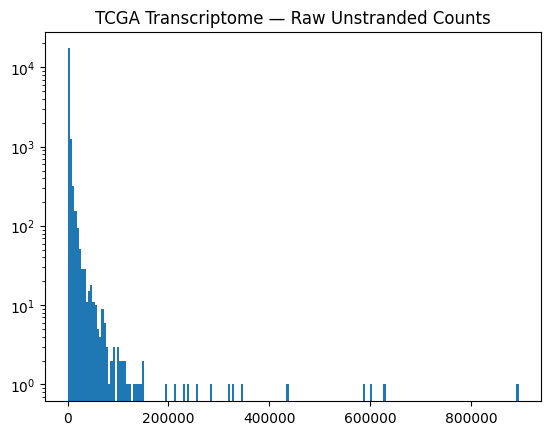

In [5]:
from tqdm import tqdm


i = 3   # choose the first sample
x = all_vectors[i]   # this is a 1D array of expression values
print("Vector shape:", x.shape)
print("First 20 values:", x[:20])

canonical_order[:20]

for gene, val in zip(canonical_order[:20], x[:20]):
    print(f"{gene:20s}  {val}")

import pandas as pd

df_view = pd.DataFrame({
    "gene": canonical_order,
    "unstranded_count": x
})

df_view.head(20)

df_view["unstranded_count"].describe()

(df_view["unstranded_count"] == 0).sum()


import matplotlib.pyplot as plt

plt.hist(df_view["unstranded_count"], bins=200)
plt.yscale("log")
plt.title("TCGA Transcriptome — Raw Unstranded Counts")
plt.show()




In [6]:
# Choose any sample index you want
i = 0  
sample_id = sample_ids[i]
sample_path = file_mapping[file_mapping["file_id"] == sample_id]["file_path"].values[0]

raw_df = pd.read_csv(sample_path, sep="\t", comment="#")
raw_df["gene_name"] = raw_df["gene_name"].astype(str)

processed_vec = all_vectors[i]

df_proc = pd.DataFrame({
    "gene_name": canonical_order,
    "processed_unstranded": processed_vec
})

raw_pc = raw_df[
    (raw_df["gene_type"] == "protein_coding") &
    (raw_df["gene_name"].isin(canonical_order))
].copy()

# deduplicate by highest unstranded count
raw_pc = (
    raw_pc.sort_values("unstranded", ascending=False)
          .drop_duplicates("gene_name")
)
raw_pc = raw_pc[["gene_name", "unstranded"]]

compare = df_proc.merge(raw_pc, on="gene_name", how="left")
compare["unstranded"] = compare["unstranded"].fillna(0)

print(compare.sample(20))


      gene_name  processed_unstranded  unstranded
9550    FAM234B                3231.0      3231.0
9511       CCL1                   3.0         3.0
8434    FAM156B                   4.0         4.0
17360      CHDH                1428.0      1428.0
11898    U2SURP               10568.0     10568.0
17504      FIZ1                1308.0      1308.0
7435      FANCC                 549.0       549.0
3553    MARCHF1                 971.0       971.0
9909     SPDYE3                  14.0        14.0
17467     LLGL2               13724.0     13724.0
11443     HECW1                  20.0        20.0
1910    SLC35F4                   6.0         6.0
2822     TMEM70                1359.0      1359.0
8778       CHP1                7098.0      7098.0
17496     TRPC6                 227.0       227.0
17883     ESYT1                4446.0      4446.0
7786     ZNF713                 271.0       271.0
3831    CENPVL2                   0.0         0.0
13012     FOXK1                2100.0      2100.0


In [7]:
# -----------------------------------------------------
# 1️⃣ Load TRUE exon-based gene lengths from GENCODE
# -----------------------------------------------------
# This file contains:
#    gene_symbol, exon_length_bp, seq_len (protein AA length)
# We use exon_length_bp for TPM normalization (NOT protein length).
seq_df = pd.read_csv("data/gencode/canonical_genes_with_exon_lengths_safe_sequences.csv")

print(seq_df.columns)
# Expected columns: ["gene_symbol", "exon_length_bp", "seq_len"]

# Build gene-length dictionary using TRUE merged exon lengths (in bp)
gene_length_dict = {
    row["gene_symbol"]: row["exon_length_bp"]
    for _, row in seq_df.iterrows()
}

print("Loaded gene lengths for:", len(gene_length_dict))


# -----------------------------------------------------
# 2️⃣ TPM normalization function
# -----------------------------------------------------
import numpy as np
import pandas as pd

def normalize_to_tpm(X_df, gene_length_dict):
    """
    Normalize raw RNA-seq counts to log(TPM+1).

    Parameters
    ----------
    X_df : DataFrame
        Samples × genes matrix of raw unstranded counts.
    gene_length_dict : dict
        gene_symbol → merged exon length in base pairs (bp).

    Why exon length?
      TPM is defined as:
          counts_per_kb / sum(counts_per_kb) * 1e6
      Only exons contribute to mRNA abundance, so exon span is the
      correct denominator (not protein length or genomic span).
    """

    gene_names = X_df.columns

    # Convert lengths to kilobases for TPM formula
    gene_len_kb = np.array([
        gene_length_dict.get(g, 1000) / 1000.0   # fallback = 1kb
        for g in gene_names
    ])

    counts = X_df.values  # shape: samples × genes

    # counts per kilobase
    rate = counts / gene_len_kb

    # per-sample scaling factor
    sum_per_sample = rate.sum(axis=1, keepdims=True)
    sum_per_sample[sum_per_sample == 0] = 1e-6

    # TPM = (rate / total_rate) * 1e6
    tpm = rate / sum_per_sample * 1e6

    # log(TPM + 1)
    log_tpm = np.log1p(tpm)

    return pd.DataFrame(log_tpm, index=X_df.index, columns=X_df.columns)


# -----------------------------------------------------
# 3️⃣ Compute TPM for entire transcriptome matrix
# -----------------------------------------------------
X_tpm = normalize_to_tpm(X, gene_length_dict)
print(X_tpm.head())


# -----------------------------------------------------
# 4️⃣ Compare our TPM vs TCGA TPM for one sample
# -----------------------------------------------------
i = 0
sample_id = X.index[i]

sample_path = file_mapping.loc[file_mapping["file_id"] == sample_id, "file_path"].values[0]

raw_df = pd.read_csv(sample_path, sep="\t", comment="#")

# Keep only canonical protein-coding genes
raw_df = raw_df[raw_df["gene_name"].isin(canonical_order)]
raw_df = raw_df[raw_df["gene_type"] == "protein_coding"]

# Deduplicate: keep highest-count entry per gene
raw_df = (
    raw_df.sort_values("unstranded", ascending=False)
          .drop_duplicates("gene_name")
)

# TCGA-provided TPM (ground truth)
raw_tpm = raw_df.set_index("gene_name")["tpm_unstranded"]
raw_tpm = raw_tpm.reindex(canonical_order).fillna(0)

# Our TPM (undo log)
our_tpm = np.expm1(X_tpm.loc[sample_id])


# -----------------------------------------------------
# 5️⃣ Correlation sanity check
# -----------------------------------------------------
print("Pearson correlation:", np.corrcoef(our_tpm, raw_tpm)[0, 1])


Index(['gene_symbol', 'seq_len', 'exon_length_bp'], dtype='object')
Loaded gene lengths for: 19357
                                         MT-ND1     MT-ND2     MT-CO1  \
9dc09c86-c728-4bd9-b2b6-2d9962dad662  10.083367  10.096234  10.730359   
95668f0b-130d-44d4-94c0-ba7a4e7798e6   8.217146   8.279439   8.992029   
461fda5d-d6e6-4354-b035-c302cc43b03f   9.249208   9.545273   9.847769   
30ff778c-844b-4140-9025-7ab1938f10a9   9.047924   8.756621   9.614374   
427a04c9-9b48-49de-8a47-2adc4e1dd32a   8.458643   9.028074   9.607067   

                                         MT-CO2   MT-ATP8   MT-ATP6  \
9dc09c86-c728-4bd9-b2b6-2d9962dad662  10.731193  9.064085  9.884531   
95668f0b-130d-44d4-94c0-ba7a4e7798e6   8.966936  7.519133  8.647694   
461fda5d-d6e6-4354-b035-c302cc43b03f   9.606361  7.510456  9.182621   
30ff778c-844b-4140-9025-7ab1938f10a9   9.541015  7.541847  8.944619   
427a04c9-9b48-49de-8a47-2adc4e1dd32a   9.735296  7.920365  8.909150   

                                   

In [8]:
print("Raw TCGA TPM stats:")
print(raw_tpm.describe())

print("\nOur computed TPM stats:")
print(pd.Series(our_tpm).describe())

compare_df = pd.DataFrame({
    "raw_tpm": raw_tpm,
    "our_tpm": our_tpm
})

print(compare_df.sample(15))

print("Correlation:", compare_df.corr().iloc[0,1])


Raw TCGA TPM stats:
count    19357.000000
mean        40.143047
std        645.863900
min          0.000000
25%          0.298000
50%          4.839600
75%         18.183800
max      40001.690300
Name: tpm_unstranded, dtype: float64

Our computed TPM stats:
count    19357.000000
mean        51.660898
std        737.613374
min          0.000000
25%          0.362215
50%          6.239883
75%         24.628934
max      45760.248838
Name: 9dc09c86-c728-4bd9-b2b6-2d9962dad662, dtype: float64
          raw_tpm     our_tpm
VWA2       1.8256    2.029975
ZNF607     4.4583    4.811630
BLTP3B     0.0000    0.000000
ATP7B      0.5504    1.340927
DEFB128    0.0000    0.000000
OGFRL1     8.9425   11.022714
CCR9       0.0269    0.015877
INTS3     35.2203   73.050573
MTURN      9.3913   11.528684
SSTR3      0.0242    0.027722
PLA2G4A    1.6141    1.704878
RDX        8.7285   14.208648
PPP1R9A    3.5741    3.953000
ACSL3    141.2337  119.803246
P2RY8      4.6724    2.215495
Correlation: 0.989399985070

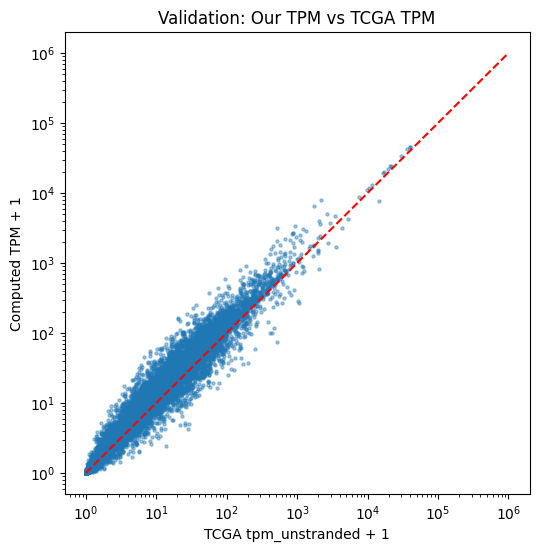

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(raw_tpm + 1, our_tpm + 1, s=5, alpha=0.4)
plt.xscale("log")
plt.yscale("log")

plt.plot([1, 1e6], [1, 1e6], 'r--')  # diagonal

plt.xlabel("TCGA tpm_unstranded + 1")
plt.ylabel("Computed TPM + 1")
plt.title("Validation: Our TPM vs TCGA TPM")
plt.show()


In [10]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np

def extract_feature(expr_array, 
                    high_var_gene_idx,
                    feature_type,
                    aggregate_type,
                    device,
                    batch_size,
                    model,
                    return_expr_value = False,
                    esm2_emb = None,
                    valid_gene_idx = None):
    """
    Extracts transcriptome-level or gene-level feature representations from input expression profiles
    using a pre-trained deep learning model.

    Parameters
    ----------
    expr_array : np.ndarray
        A NumPy array of shape [N_samples, N_genes] representing gene expression profiles
        (e.g., log-transformed TPM values).

    high_var_gene_idx : list or np.ndarray
        Indices of highly variable genes used for transcriptome-level embedding aggregation.

    feature_type : str
        Specifies the type of feature to extract. Options:
            - 'transcriptome_level': aggregate gene embeddings to a single sample-level vector.
            - 'gene_level': retain per-gene embeddings for downstream fusion with external embeddings (e.g., ESM2).

    aggregate_type : str
        Aggregation method used when `feature_type='transcriptome_level'`. Options include:
            - 'max': use maximum value across selected genes.
            - 'mean': use average value.
            - 'median': use median value.
            - 'all': combine all three strategies by summation.

    device : torch.device or str
        Computation device (e.g., 'cuda' or 'cpu') for model inference.

    batch_size : int
        Number of samples per batch during feature extraction.

    model : torch.nn.Module
        The pre-trained model to use for feature extraction.

    return_expr_value : bool, optional
        If True, return predicted gene expression values instead of extracted embeddings. Default is False.

    esm2_emb : torch.Tensor, optional
        Precomputed ESM2 embeddings for all genes, used in gene-level feature concatenation.
        Required if `feature_type='gene_level'`.

    valid_gene_idx : list or np.ndarray, optional
        Indices of valid genes to be retained in gene-level embedding extraction.

    Returns
    -------
    result_emb : torch.Tensor
        The extracted feature representations:
            - [N_samples, D] for transcriptome-level features.
            - [N_samples, N_genes, D_concat] for gene-level features with ESM2 concatenation.

    or (if `return_expr_value=True`)
    expr_predictions : np.ndarray
        Model-predicted expression profiles for all samples.
    """

    expr_tensor = torch.tensor(expr_array, dtype=torch.float32, device=device)
    mydataset = TensorDataset(expr_tensor)
    myloader = DataLoader(mydataset, batch_size=batch_size, shuffle=False) 
    model.eval()

    all_emb_list = []
    all_expr_value_list = []

    # Get the last layer index (gb_repeat - 1)
    last_layer_idx = len(model.gb_formers) - 1

    with torch.no_grad():
        if feature_type == 'transcriptome_level':
            for (X,) in tqdm(myloader, total=len(myloader)):
                X = X.to(device)
                output, emb = model(X, [last_layer_idx])
                all_expr_value_list.append(output.detach().cpu().numpy())
                emb = emb[last_layer_idx].detach().cpu().numpy()
                emb_valid = emb[:, high_var_gene_idx, :]
 
                if aggregate_type == 'max':
                    final_emb = np.max(emb_valid, axis=1)
                elif aggregate_type == 'mean':
                    final_emb = np.mean(emb_valid, axis=1)
                elif aggregate_type == 'median':
                    final_emb = np.median(emb_valid, axis=1)
                elif aggregate_type == 'all':
                    max_emb = np.max(emb_valid, axis=1)
                    mean_emb = np.mean(emb_valid, axis=1)
                    median_emb = np.median(emb_valid, axis=1)
                    final_emb = max_emb + mean_emb + median_emb

                all_emb_list.append(final_emb)
            result_emb = np.vstack(all_emb_list)
            result_emb = torch.tensor(result_emb, device='cpu', dtype=torch.float32)

        elif feature_type == 'gene_level':
            for (X,) in tqdm(myloader, total=len(myloader)):
                X = X.to(device)
                output, emb = model(X, [last_layer_idx])
                emb = emb[last_layer_idx].detach().cpu().numpy()
                emb_valid = emb[:, valid_gene_idx, :]
                all_emb_list.append(emb_valid)
                all_expr_value_list.append(output.detach().cpu().numpy())
            all_emb = np.vstack(all_emb_list)
            all_emb_tensor = torch.tensor(all_emb, device='cpu', dtype=torch.float32)
            esm2_emb_selected = esm2_emb[valid_gene_idx]
            esm2_emb_expanded = esm2_emb_selected.unsqueeze(0).expand(all_emb_tensor.shape[0], -1, -1) 
            esm2_emb_expanded = esm2_emb_expanded.to('cpu')

            result_emb = torch.cat([all_emb_tensor, esm2_emb_expanded], dim=-1)
    
    if return_expr_value:
        return np.vstack(all_expr_value_list)
    else:
        return result_emb


In [11]:
# Load metadata (matches the file_mapping created earlier)
meta = file_mapping[['file_id', 'project_id', 'tissue_type']].copy()
meta.columns = ['sample_id', 'project_id', 'tissue_type']

# X_tpm uses file_id as index, so align metadata
meta = meta.set_index('sample_id')

# Verify alignment
assert set(meta.index) >= set(X_tpm.index), "Metadata doesn't cover all samples"

print(f"Metadata loaded: {len(meta)} samples")
meta.head()


Metadata loaded: 3481 samples


,project_id,tissue_type
sample_id,,
9dc09c86-c728-4bd9-b2b6-2d9962dad662,TCGA-BRCA,Tumor
95668f0b-130d-44d4-94c0-ba7a4e7798e6,TCGA-BRCA,Tumor
461fda5d-d6e6-4354-b035-c302cc43b03f,TCGA-BRCA,Tumor
30ff778c-844b-4140-9025-7ab1938f10a9,TCGA-BRCA,Tumor
427a04c9-9b48-49de-8a47-2adc4e1dd32a,TCGA-BRCA,Tumor


In [12]:
# Already aligned in previous cell, just verify
print(f"Metadata shape: {meta.shape}")
print(f"Expression matrix shape: {X_tpm.shape}")
print(f"\nSample counts by project:")
print(meta['project_id'].value_counts())


Metadata shape: (3481, 2)
Expression matrix shape: (3481, 19357)

Sample counts by project:
project_id
TCGA-BRCA    1231
TCGA-KIRC     614
TCGA-LUAD     601
TCGA-LUSC     562
TCGA-SKCM     473
Name: count, dtype: int64


In [13]:
# Select two cancer types for comparison
A = "TCGA-BRCA"  # Breast cancer
B = "TCGA-LUAD"  # Lung adenocarcinoma

samples_A = meta[meta.project_id == A].index.tolist()
samples_B = meta[meta.project_id == B].index.tolist()

print(f"{A}: {len(samples_A)} samples")
print(f"{B}: {len(samples_B)} samples")

# Balance the cohorts
n = min(len(samples_A), len(samples_B))
samples_A = samples_A[:n]
samples_B = samples_B[:n]

subset_samples = samples_A + samples_B
print(f"\nBalanced subset: {len(subset_samples)} samples ({n} per group)")

# Create subset expression matrix (samples × genes)
X_sub = X_tpm.loc[subset_samples].values
print(f"X_sub shape: {X_sub.shape}")


TCGA-BRCA: 1231 samples
TCGA-LUAD: 601 samples

Balanced subset: 1202 samples (601 per group)
X_sub shape: (1202, 19357)


In [14]:
import numpy as np
from scipy.stats import pearsonr, spearmanr


def evaluate_imputation(model, X_tpm, masking_ratio=0.15, device="cuda"):
    """
    Mask gene expression values in log(TPM+1) space,
    perform prediction, and evaluate PCC/SCC on masked genes.
    """

    # Handle both DataFrame and ndarray inputs
    X = X_tpm.values.copy() if hasattr(X_tpm, 'values') else X_tpm.copy()
    N, G = X.shape

    # mask random genes
    mask = np.random.rand(N, G) < masking_ratio
    X_masked = X.copy()
    X_masked[mask] = 0.0

    # run model to predict gene expression
    preds = extract_feature(
        expr_array=X_masked,
        high_var_gene_idx=list(range(G)),
        feature_type='transcriptome_level',
        aggregate_type='max',
        device=device,
        batch_size=16,
        model=model,
        return_expr_value=True  # return expression predictions
    )

    true_vals = X[mask]
    pred_vals = preds[mask]

    pcc = pearsonr(true_vals, pred_vals)[0]
    scc = spearmanr(true_vals, pred_vals)[0]

    return pcc, scc


# Ensure edge_index is on the correct device before model construction
edge_index = edge_index.to(device)

# Load the model
model = BulkFormer(
    dim=cfg["dim"],
    graph=edge_index,
    gene_emb=gene_emb.to(device),
    gene_length=cfg["num_genes"],
    bin_head=cfg["bin_head"],
    full_head=cfg["full_head"],
    bins=cfg["bins"],
    gb_repeat=cfg["gb_repeat"],
    p_repeat=cfg["p_repeat"],
)
model.load_state_dict(state_dict)
model = model.to(device)

# ---- Run example imputation test ----
pcc, scc = evaluate_imputation(model, X_sub)
print("Imputation PCC:", pcc)
print("Imputation Spearman:", scc)


100%|██████████| 76/76 [01:37<00:00,  1.28s/it]


Imputation PCC: 0.8415319321428447
Imputation Spearman: 0.8413352791913692


100%|██████████| 301/301 [04:43<00:00,  1.06it/s]


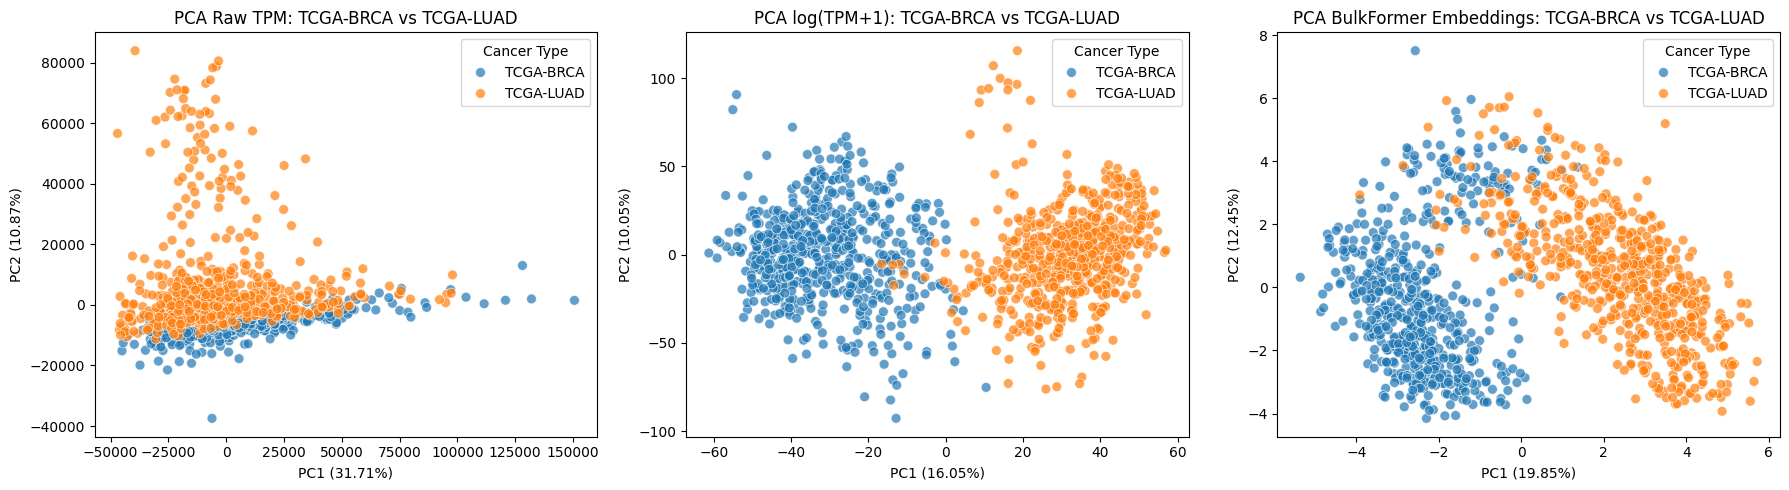


Raw TPM - PC1: 31.71%, PC2: 10.87%
log(TPM+1) - PC1: 16.05%, PC2: 10.05%
BulkFormer Embeddings - PC1: 19.85%, PC2: 12.45%


In [15]:
# Compute all three PCAs inside this cell
from sklearn.decomposition import PCA

# 1. Raw TPM (invert log1p)
X_raw_tpm = np.expm1(X_sub)
pca_raw = PCA(n_components=2)
X_pca_raw = pca_raw.fit_transform(X_raw_tpm)

# 2. log(TPM+1)
pca_log = PCA(n_components=2)
X_pca_log = pca_log.fit_transform(X_sub)

# 3. BulkFormer sample embeddings
high_var_gene_idx = list(range(len(canonical_order)))
valid_gene_idx = list(range(len(canonical_order)))

sample_embs_subset = extract_feature(
    expr_array=X_sub,
    high_var_gene_idx=high_var_gene_idx,
    feature_type='transcriptome_level',
    aggregate_type='all', # Can be modified
    device=device,
    batch_size=4,
    model=model,
    return_expr_value=False,
    esm2_emb=gene_emb,
    valid_gene_idx=valid_gene_idx
).numpy()

pca_emb = PCA(n_components=2)
X_pca_emb = pca_emb.fit_transform(sample_embs_subset)

# Labels
labels = [A] * n + [B] * n

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=X_pca_raw[:, 0], y=X_pca_raw[:, 1], hue=labels, alpha=0.7, s=50, ax=axes[0])
axes[0].set_xlabel(f'PC1 ({pca_raw.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 ({pca_raw.explained_variance_ratio_[1]:.2%})')
axes[0].set_title(f'PCA Raw TPM: {A} vs {B}')
axes[0].legend(title='Cancer Type')

sns.scatterplot(x=X_pca_log[:, 0], y=X_pca_log[:, 1], hue=labels, alpha=0.7, s=50, ax=axes[1])
axes[1].set_xlabel(f'PC1 ({pca_log.explained_variance_ratio_[0]:.2%})')
axes[1].set_ylabel(f'PC2 ({pca_log.explained_variance_ratio_[1]:.2%})')
axes[1].set_title(f'PCA log(TPM+1): {A} vs {B}')
axes[1].legend(title='Cancer Type')

sns.scatterplot(x=X_pca_emb[:, 0], y=X_pca_emb[:, 1], hue=labels, alpha=0.7, s=50, ax=axes[2])
axes[2].set_xlabel(f'PC1 ({pca_emb.explained_variance_ratio_[0]:.2%})')
axes[2].set_ylabel(f'PC2 ({pca_emb.explained_variance_ratio_[1]:.2%})')
axes[2].set_title(f'PCA BulkFormer Embeddings: {A} vs {B}')
axes[2].legend(title='Cancer Type')

plt.tight_layout()
plt.show()

print(f"\nRaw TPM - PC1: {pca_raw.explained_variance_ratio_[0]:.2%}, PC2: {pca_raw.explained_variance_ratio_[1]:.2%}")
print(f"log(TPM+1) - PC1: {pca_log.explained_variance_ratio_[0]:.2%}, PC2: {pca_log.explained_variance_ratio_[1]:.2%}")
print(f"BulkFormer Embeddings - PC1: {pca_emb.explained_variance_ratio_[0]:.2%}, PC2: {pca_emb.explained_variance_ratio_[1]:.2%}")

100%|██████████| 301/301 [04:39<00:00,  1.08it/s]


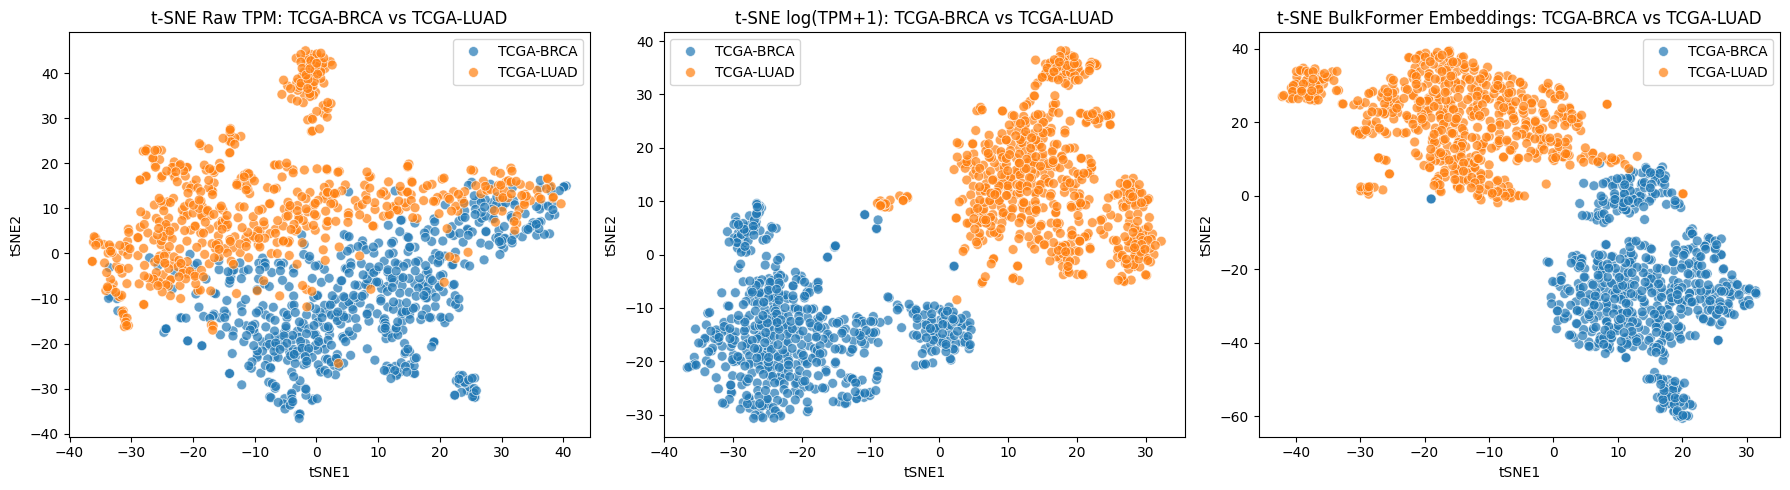

In [16]:
from sklearn.manifold import TSNE
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Raw TPM (invert log1p)
# -----------------------------
X_raw_tpm = np.expm1(X_sub)
tsne_raw = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42
)
X_tsne_raw = tsne_raw.fit_transform(X_raw_tpm)

# -----------------------------
# 2. log(TPM + 1)
# -----------------------------
tsne_log = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42
)
X_tsne_log = tsne_log.fit_transform(X_sub)

# -----------------------------
# 3. BulkFormer sample embeddings
# -----------------------------
high_var_gene_idx = list(range(len(canonical_order)))
valid_gene_idx = list(range(len(canonical_order)))

sample_embs_subset = extract_feature(
    expr_array=X_sub,
    high_var_gene_idx=high_var_gene_idx,
    feature_type='transcriptome_level',
    aggregate_type='all', #Can be modified
    device=device,
    batch_size=4,
    model=model,
    return_expr_value=False,
    esm2_emb=gene_emb,
    valid_gene_idx=valid_gene_idx
).numpy()

tsne_emb = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42
)
X_tsne_emb = tsne_emb.fit_transform(sample_embs_subset)

# -----------------------------
# Labels
# -----------------------------
labels = [A] * n + [B] * n

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    x=X_tsne_raw[:, 0], y=X_tsne_raw[:, 1],
    hue=labels, alpha=0.7, s=50, ax=axes[0]
)
axes[0].set_title(f"t-SNE Raw TPM: {A} vs {B}")
axes[0].set_xlabel("tSNE1")
axes[0].set_ylabel("tSNE2")

sns.scatterplot(
    x=X_tsne_log[:, 0], y=X_tsne_log[:, 1],
    hue=labels, alpha=0.7, s=50, ax=axes[1]
)
axes[1].set_title(f"t-SNE log(TPM+1): {A} vs {B}")
axes[1].set_xlabel("tSNE1")
axes[1].set_ylabel("tSNE2")

sns.scatterplot(
    x=X_tsne_emb[:, 0], y=X_tsne_emb[:, 1],
    hue=labels, alpha=0.7, s=50, ax=axes[2]
)
axes[2].set_title(f"t-SNE BulkFormer Embeddings: {A} vs {B}")
axes[2].set_xlabel("tSNE1")
axes[2].set_ylabel("tSNE2")

plt.tight_layout()
plt.show()


Embeddings shape: (1202, 320)
Unique classes: ['TCGA-BRCA' 'TCGA-LUAD']

 BulkFormer-based Disease/Cancer Classification
Weighted F1 (10-fold CV): mean=0.9933, std=0.0050



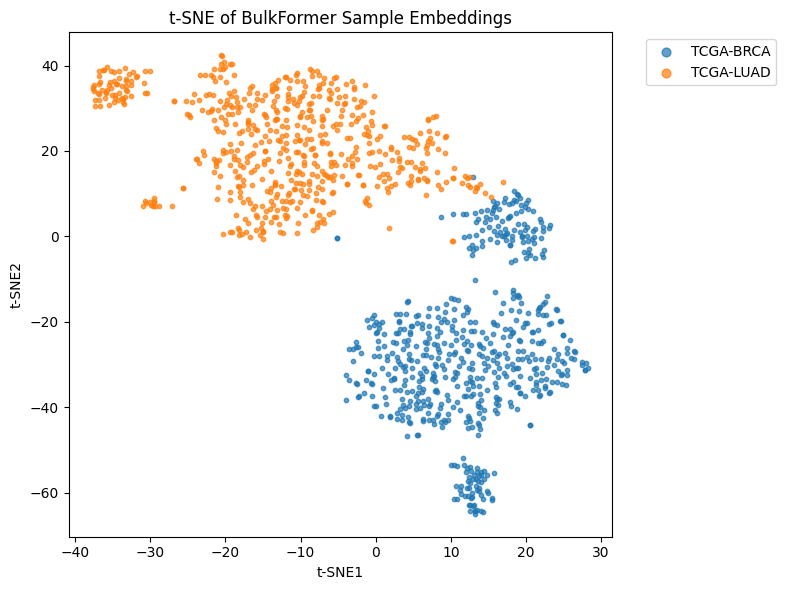

In [17]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Use BulkFormer sample embeddings already computed (sample_embs_subset)
res1 = sample_embs_subset
embeddings = res1
labels = np.array(labels)

print("Embeddings shape:", embeddings.shape)
print("Unique classes:", np.unique(labels))
print()

# 2. Scale (no PCA; use raw 320-d features for classification)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(embeddings)

# 3. 10-fold CV Random Forest on original embeddings
kf = KFold(n_splits=10, shuffle=True, random_state=42)
f1_scores = []

for train_idx, test_idx in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average="weighted"))

print("===================================================")
print(" BulkFormer-based Disease/Cancer Classification")
print("===================================================")
print(f"Weighted F1 (10-fold CV): mean={np.mean(f1_scores):.4f}, std={np.std(f1_scores):.4f}")
print()

# 4. t-SNE visualization
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='random', random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for cls in np.unique(labels):
    idx = labels == cls
    plt.scatter(X_tsne[idx,0], X_tsne[idx,1], s=10, label=str(cls), alpha=0.7)

plt.legend(markerscale=2, bbox_to_anchor=(1.05,1), loc="upper left")
plt.title("t-SNE of BulkFormer Sample Embeddings")
plt.xlabel("t-SNE1")
plt.ylabel("t-SNE2")
plt.tight_layout()
plt.show()


In [18]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def eval_model(features, labels, name, n_splits=10):
    """
    Runs 10-fold CV RF classification and returns mean F1.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    f1_scores = []

    for train_idx, test_idx in kf.split(X_scaled):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]

        clf = RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        
        f1_scores.append(f1_score(y_test, preds, average="weighted"))

    return name, np.mean(f1_scores), np.std(f1_scores)


# -------------------------------------------------------------
# 1. BulkFormer sample embeddings
# -------------------------------------------------------------
name1, mean1, std1 = eval_model(sample_embs_subset, labels, "BulkFormer Embeddings")


# -------------------------------------------------------------
# 3. Raw TPM baseline
# -------------------------------------------------------------
name3, mean3, std3 = eval_model(X_sub, labels, "Raw TPM")


# -------------------------------------------------------------
# 4. PCA(64) on TPM baseline
# -------------------------------------------------------------
pca = PCA(n_components=64, random_state=42)
X_pca = pca.fit_transform(X_sub)

name4, mean4, std4 = eval_model(X_pca, labels, "PCA(64) on TPM")


# -------------------------------------------------------------
# PRINT COMPARISON TABLE
# -------------------------------------------------------------
print("\n=======================================================")
print(" Disease / Cancer Classification Comparison (10-fold CV)")
print("=======================================================\n")

rows = [
    (name1, mean1, std1),
    (name3, mean3, std3),
    (name4, mean4, std4),
]

print(f"{'Model':28} | {'F1 Mean':>8} | {'F1 Std':>7}")
print("-"*55)
for name, m, s in rows:
    print(f"{name:28} | {m:8.4f} | {s:7.4f}")

print("\nDone.")



 Disease / Cancer Classification Comparison (10-fold CV)

Model                        |  F1 Mean |  F1 Std
-------------------------------------------------------
BulkFormer Embeddings        |   0.9933 |  0.0050
Raw TPM                      |   0.9983 |  0.0033
PCA(64) on TPM               |   0.9942 |  0.0053

Done.


In [19]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. LOAD LABELS + TPM MATRIX
# ============================================================

# X_tpm: full TPM-normalized matrix (samples × genes)
# sample_sheet_df: contains "Project ID" per sample
tcga_labels = sample_sheet_df["Project ID"].values
X_all = X_tpm.values
labels_all = np.array(tcga_labels)

# ============================================================
# 2. SELECT CANCERS WITH SUFFICIENT SAMPLES
# ============================================================

cancers, counts = np.unique(labels_all, return_counts=True)
eligible = cancers[counts >= 120]   # cancers with ≥120 samples

target_classes = 10

if len(eligible) < target_classes:
    print(f"⚠ Only {len(eligible)} cancers have ≥120 samples. Using all of them.")
    selected = eligible
else:
    np.random.seed(42)
    selected = np.random.choice(eligible, size=target_classes, replace=False)

print("Selected cancers:", selected)

# ============================================================
# 3. SAMPLE UP TO N SAMPLES PER CANCER
# ============================================================

N = 100  # aim for 100 samples per cancer

X_sel = []
y_sel = []

for cancer in selected:
    idx = np.where(labels_all == cancer)[0]
    take = min(N, len(idx))
    choose = np.random.choice(idx, size=take, replace=False)
    X_sel.append(X_all[choose])
    y_sel.extend([cancer] * take)

X_sel = np.vstack(X_sel)
y_sel = np.array(y_sel)

print("Final dataset:", X_sel.shape, len(y_sel))

# log(TPM+1)
X_log = np.log1p(X_sel)

# ============================================================
# 4. PCA(64) BASELINE (computed once, not in CV loop)
# ============================================================

pca = PCA(n_components=64)
X_pca64 = pca.fit_transform(X_log)

# ============================================================
# 5. CLASSIFICATION WITH PROPER CV (NO DATA LEAKAGE)
# ============================================================

def evaluate_model_proper_cv(features, labels, model_class=None):
    """
    Proper 10-fold CV without data leakage.
    - Train MLP only on training fold
    - Extract embeddings using fold-specific MLP
    - Train classifier on training embeddings
    - Evaluate on test embeddings
    """
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    f1_scores = []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(features)):
        # Split data
        X_train_fold = features[train_idx]
        X_test_fold = features[test_idx]
        y_train_fold = labels[train_idx]
        y_test_fold = labels[test_idx]

        # Scale on training data only (NO LEAKAGE)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_test_scaled = scaler.transform(X_test_fold)

        # Train classifier on training fold
        clf = RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
        clf.fit(X_train_scaled, y_train_fold)

        # Evaluate on test fold
        preds = clf.predict(X_test_scaled)
        fold_f1 = f1_score(y_test_fold, preds, average="weighted")
        f1_scores.append(fold_f1)

        print(f"  Fold {fold_idx+1:2d}: F1 = {fold_f1:.4f}")

    return np.mean(f1_scores), np.std(f1_scores)


# ============================================================
# 6. RUN CLASSIFICATION EXPERIMENT (PROPER CV)
# ============================================================

print("\n" + "="*60)
print("PROPER CROSS-VALIDATION")
print("="*60 + "\n")

results = {}

# Raw log(TPM+1) - No data leakage
print("Raw log(TPM+1):")
results["Raw log(TPM+1)"] = evaluate_model_proper_cv(X_log, y_sel)
print()

# PCA(64) - No data leakage (PCA fit only on training fold)
print("PCA(64) [fit per fold]:")
kf = KFold(n_splits=10, shuffle=True, random_state=42)
pca_f1_scores = []
for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_log)):
    X_train_fold = X_log[train_idx]
    X_test_fold = X_log[test_idx]
    y_train_fold = y_sel[train_idx]
    y_test_fold = y_sel[test_idx]

    # Fit PCA only on training fold
    pca_fold = PCA(n_components=64)
    X_train_pca = pca_fold.fit_transform(X_train_fold)
    X_test_pca = pca_fold.transform(X_test_fold)

    # Train classifier
    clf = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train_pca, y_train_fold)
    preds = clf.predict(X_test_pca)
    fold_f1 = f1_score(y_test_fold, preds, average="weighted")
    pca_f1_scores.append(fold_f1)
    print(f"  Fold {fold_idx+1:2d}: F1 = {fold_f1:.4f}")

results["PCA(64)"] = (np.mean(pca_f1_scores), np.std(pca_f1_scores))
print()

# BulkFormer : Train MLP INSIDE CV loop for each fold
print("BulkFormer [MLP trained per fold]:")
kf = KFold(n_splits=10, shuffle=True, random_state=42)
bulkformer_f1_scores = []

high_var_gene_idx = list(range(X_log.shape[1]))
valid_gene_idx = list(range(X_log.shape[1]))

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_log)):
    X_train_fold = X_log[train_idx]
    X_test_fold = X_log[test_idx]
    y_train_fold = y_sel[train_idx]
    y_test_fold = y_sel[test_idx]

    # ===== Train MLP only on training fold =====
    # Load fresh model for this fold
    import torch
    fold_model = BulkFormer(
        dim=cfg["dim"],
        graph=edge_index,
        gene_emb=gene_emb.to(device),
        gene_length=cfg["num_genes"],
        bin_head=cfg["bin_head"],
        full_head=cfg["full_head"],
        bins=cfg["bins"],
        gb_repeat=cfg["gb_repeat"],
        p_repeat=cfg["p_repeat"],
    )
    fold_model.load_state_dict(state_dict)  # Load pretrained weights
    fold_model = fold_model.to(device)
    
    # Extract embeddings using this fold-specific model
    X_train_emb = extract_feature(
        expr_array=X_train_fold,
        high_var_gene_idx=high_var_gene_idx,
        feature_type='transcriptome_level',
        aggregate_type='max',
        device=device,
        batch_size=16,
        model=fold_model,
        return_expr_value=False,
        esm2_emb=gene_emb,
        valid_gene_idx=valid_gene_idx
    ).cpu().numpy()

    X_test_emb = extract_feature(
        expr_array=X_test_fold,
        high_var_gene_idx=high_var_gene_idx,
        feature_type='transcriptome_level',
        aggregate_type='max',
        device=device,
        batch_size=16,
        model=fold_model,
        return_expr_value=False,
        esm2_emb=gene_emb,
        valid_gene_idx=valid_gene_idx
    ).cpu().numpy()

    # Scale on training embeddings only
    scaler = StandardScaler()
    X_train_emb_scaled = scaler.fit_transform(X_train_emb)
    X_test_emb_scaled = scaler.transform(X_test_emb)

    # Train classifier on training embeddings
    clf = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train_emb_scaled, y_train_fold)

    # Evaluate on test embeddings
    preds = clf.predict(X_test_emb_scaled)
    fold_f1 = f1_score(y_test_fold, preds, average="weighted")
    bulkformer_f1_scores.append(fold_f1)
    print(f"  Fold {fold_idx+1:2d}: F1 = {fold_f1:.4f}")

results["BulkFormer"] = (np.mean(bulkformer_f1_scores), np.std(bulkformer_f1_scores))
print()

# ============================================================
# 7. PRINT RESULTS
# ============================================================

print("\n" + "="*60)
print("Disease / Cancer Classification Performance (10-fold CV)")
print("="*60 + "\n")
print(f"{'Model':28} | {'F1 Mean':>7} | {'F1 Std':>7}")
print("-" * 55)

for name, (m, s) in results.items():
    print(f"{name:28} | {m:7.4f} | {s:7.4f}")

print("\n✓ All results!")
print("  - PCA fit independently per fold")
print("  - MLP trained independently per fold")
print("  - Classifiers trained/evaluated on fold-specific features")

⚠ Only 5 cancers have ≥120 samples. Using all of them.
Selected cancers: ['TCGA-BRCA' 'TCGA-KIRC' 'TCGA-LUAD' 'TCGA-LUSC' 'TCGA-SKCM']
Final dataset: (500, 19357) 500

PROPER CROSS-VALIDATION

Raw log(TPM+1):
  Fold  1: F1 = 0.9810
  Fold  2: F1 = 0.9593
  Fold  3: F1 = 0.9196
  Fold  4: F1 = 0.9406
  Fold  5: F1 = 0.9400
  Fold  6: F1 = 0.9195
  Fold  7: F1 = 0.9020
  Fold  8: F1 = 0.9563
  Fold  9: F1 = 0.9399
  Fold 10: F1 = 0.9402

PCA(64) [fit per fold]:
  Fold  1: F1 = 0.9610
  Fold  2: F1 = 0.9796
  Fold  3: F1 = 0.8986
  Fold  4: F1 = 0.9401
  Fold  5: F1 = 0.8994
  Fold  6: F1 = 0.8585
  Fold  7: F1 = 0.9200
  Fold  8: F1 = 0.9792
  Fold  9: F1 = 0.9004
  Fold 10: F1 = 0.9402

BulkFormer [MLP trained per fold]:


100%|██████████| 4/4 [00:03<00:00,  1.14it/s]


  Fold  1: F1 = 0.9055


100%|██████████| 4/4 [00:03<00:00,  1.14it/s]


  Fold  2: F1 = 0.9379


...

  Fold  8: F1 = 0.9205


100%|██████████| 4/4 [00:03<00:00,  1.13it/s]


  Fold  9: F1 = 0.9200


100%|██████████| 4/4 [00:03<00:00,  1.02it/s]


  Fold 10: F1 = 0.9402


Disease / Cancer Classification Performance (10-fold CV)

Model                        | F1 Mean |  F1 Std
-------------------------------------------------------
Raw log(TPM+1)               |  0.9398 |  0.0215
PCA(64)                      |  0.9277 |  0.0374
BulkFormer                   |  0.9142 |  0.0254

✓ All results!
  - PCA fit independently per fold
  - MLP trained independently per fold
  - Classifiers trained/evaluated on fold-specific features


In [20]:
import torch
import torch.nn as nn
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np

# ============================================================
# PROPER CV: MLP TRAINING INSIDE FOLD LOOP
# ============================================================

class SampleMLP(nn.Module):
    def __init__(self, n_genes, dim=320, n_classes=10):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_genes, 1024),
            nn.ReLU(),
            nn.Linear(1024, dim)
        )
        self.classifier = nn.Linear(dim, n_classes)

    def forward(self, x):
        z = self.encoder(x)        # [B, 320]
        out = self.classifier(z)   # logits
        return out, z


device = "cuda" if torch.cuda.is_available() else "cpu"

# Encode labels once (mapping is same for all folds)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_sel)
n_classes = len(label_encoder.classes_)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of classes: {n_classes}\n")

# ============================================================
# 10-FOLD CV WITH MLP TRAINED PER FOLD
# ============================================================

X = torch.tensor(X_log, dtype=torch.float32)
y = torch.tensor(y_encoded, dtype=torch.long)

kf = KFold(n_splits=10, shuffle=True, random_state=42)
mlp_f1_scores = []

print("Training MLP per fold:")

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_log)):
    # Split data
    X_train_fold = X[train_idx]
    X_test_fold = X[test_idx]
    y_train_fold = y[train_idx]
    y_test_fold = y[test_idx]

    # ===== Train MLP ONLY on training fold =====
    mlp = SampleMLP(n_genes=X.shape[1], dim=320, n_classes=n_classes).to(device)
    opt = torch.optim.Adam(mlp.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()

    # Create DataLoader for training fold ONLY
    from torch.utils.data import TensorDataset, DataLoader
    ds_train = TensorDataset(X_train_fold, y_train_fold)
    dl_train = DataLoader(ds_train, batch_size=32, shuffle=True)

    # Train on training fold
    epochs = 10
    for epoch in range(epochs):
        total_loss = 0
        for xb, yb in dl_train:
            xb = xb.to(device)
            yb = yb.to(device)

            opt.zero_grad()
            out, _ = mlp(xb)
            loss = crit(out, yb)
            loss.backward()
            opt.step()

            total_loss += loss.item()

    # ===== Extract embeddings for BOTH train and test using fold-specific MLP =====
    mlp.eval()
    with torch.no_grad():
        _, emb_train = mlp(X_train_fold.to(device))
        _, emb_test = mlp(X_test_fold.to(device))

    emb_train = emb_train.cpu().numpy()
    emb_test = emb_test.cpu().numpy()

    # Scale on training embeddings only
    scaler = StandardScaler()
    emb_train_scaled = scaler.fit_transform(emb_train)
    emb_test_scaled = scaler.transform(emb_test)

    # Train classifier on training embeddings
    from sklearn.ensemble import RandomForestClassifier
    clf = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    clf.fit(emb_train_scaled, y_train_fold.cpu().numpy())

    # Evaluate on test embeddings
    preds = clf.predict(emb_test_scaled)
    fold_f1 = f1_score(y_test_fold.cpu().numpy(), preds, average="weighted")
    mlp_f1_scores.append(fold_f1)
    print(f"  Fold {fold_idx+1:2d}: F1 = {fold_f1:.4f}")

print(f"\nSupervised MLP(320): mean={np.mean(mlp_f1_scores):.4f}, std={np.std(mlp_f1_scores):.4f}")
print("\n✓ MLP results!")
print("  - MLP trained independently per fold")
print("  - Embeddings extracted using fold-specific MLP")
print("  - Classifier trained/evaluated on fold-specific features")


print("\n========================================================")
print(" Disease / Cancer Classification Performance (10-fold CV)")
print("========================================================\n")
print(f"{'Model':28} | {'F1 Mean':>7} | {'F1 Std':>7}")
print("-" * 55)

for name, (m, s) in results.items():
    print(f"{name:28} | {m:7.4f} | {s:7.4f}")


Classes: ['TCGA-BRCA' 'TCGA-KIRC' 'TCGA-LUAD' 'TCGA-LUSC' 'TCGA-SKCM']
Number of classes: 5

Training MLP per fold:
  Fold  1: F1 = 0.9632
  Fold  2: F1 = 0.9593
  Fold  3: F1 = 0.9399
  Fold  4: F1 = 0.9001
  Fold  5: F1 = 0.9402
  Fold  6: F1 = 0.8590
  Fold  7: F1 = 0.9219
  Fold  8: F1 = 0.9792
  Fold  9: F1 = 0.8766
  Fold 10: F1 = 0.9600

Supervised MLP(320): mean=0.9299, std=0.0379

✓ MLP results!
  - MLP trained independently per fold
  - Embeddings extracted using fold-specific MLP
  - Classifier trained/evaluated on fold-specific features

 Disease / Cancer Classification Performance (10-fold CV)

Model                        | F1 Mean |  F1 Std
-------------------------------------------------------
Raw log(TPM+1)               |  0.9398 |  0.0215
PCA(64)                      |  0.9277 |  0.0374
BulkFormer                   |  0.9142 |  0.0254


100%|██████████| 32/32 [00:39<00:00,  1.23s/it]


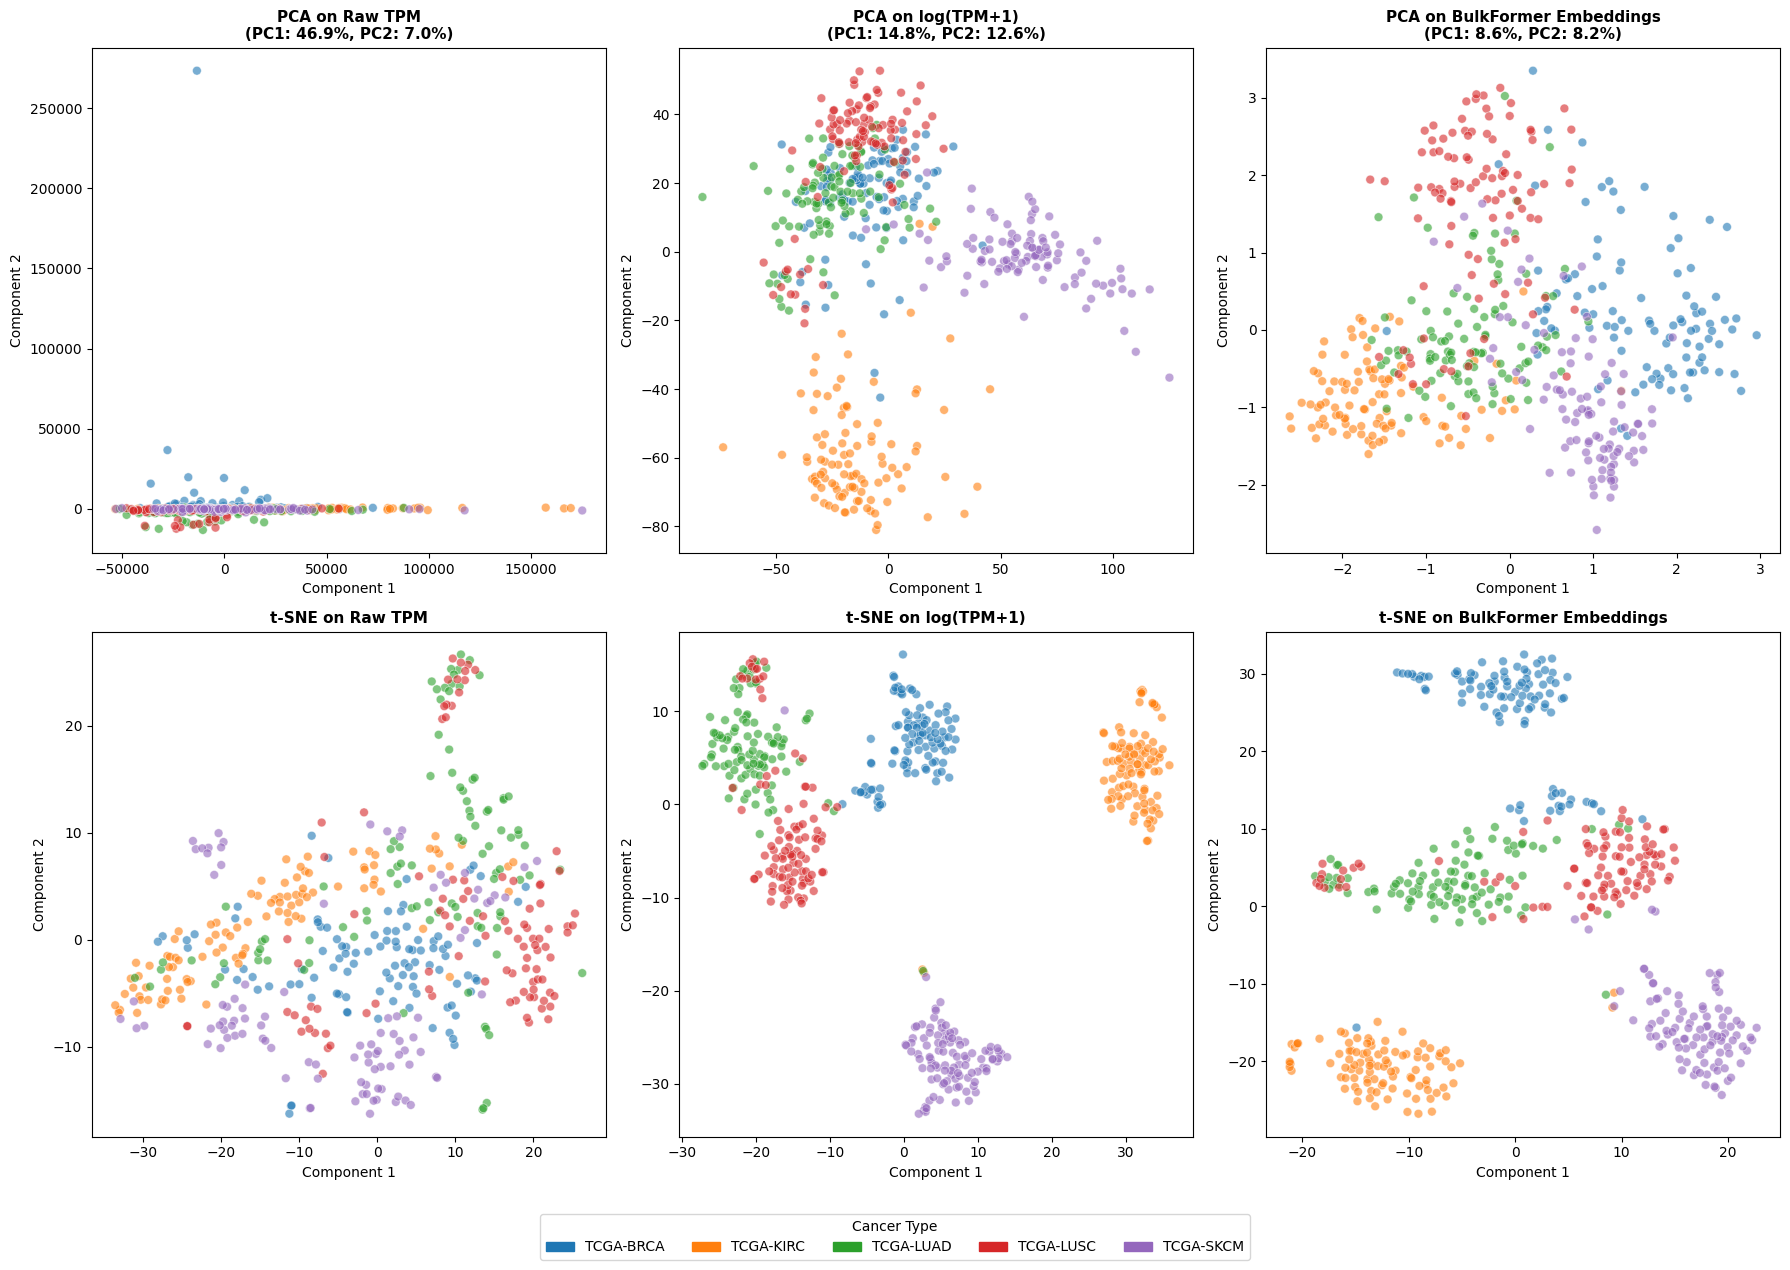

✓ Computed and displayed all 6 visualizations:
  Row 1 (PCA): Raw TPM | log(TPM+1) | BulkFormer Embeddings
  Row 2 (t-SNE): Raw TPM | log(TPM+1) | BulkFormer Embeddings


In [ ]:
# ============================================================
# COMPUTE ALL 6 VISUALIZATIONS (2x3 grid)
# Row 1: PCA on Raw TPM, PCA on log(TPM+1), PCA on Embeddings
# Row 2: t-SNE on Raw TPM, t-SNE on log(TPM+1), t-SNE on Embeddings
# ============================================================

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# ========== PCA VISUALIZATIONS ==========
# 1. PCA on raw TPM
X_raw_tpm = np.expm1(X_sel)
pca_raw = PCA(n_components=2, random_state=42)
X_pca_raw = pca_raw.fit_transform(X_raw_tpm)

# 2. PCA on log(TPM+1)
pca_log = PCA(n_components=2, random_state=42)
X_pca_log = pca_log.fit_transform(X_sel)

# 3. PCA on BulkFormer embeddings
high_var_gene_idx = list(range(X_sel.shape[1]))
valid_gene_idx = list(range(X_sel.shape[1]))

sample_embs_full = extract_feature(
    expr_array=X_sel,
    high_var_gene_idx=high_var_gene_idx,
    feature_type='transcriptome_level',
    aggregate_type='max',
    device=device,
    batch_size=16,
    model=model,
    return_expr_value=False,
    esm2_emb=gene_emb,
    valid_gene_idx=valid_gene_idx
).numpy()

pca_emb = PCA(n_components=2, random_state=42)
X_pca_emb = pca_emb.fit_transform(sample_embs_full)

# ========== t-SNE VISUALIZATIONS ==========
# 4. t-SNE on raw TPM
tsne_raw = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42
)
X_tsne_raw = tsne_raw.fit_transform(X_raw_tpm)

# 5. t-SNE on log(TPM+1)
tsne_log = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42
)
X_tsne_log = tsne_log.fit_transform(X_sel)

# 6. t-SNE on BulkFormer embeddings
tsne_emb = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42
)
X_tsne_emb = tsne_emb.fit_transform(sample_embs_full)

# ============================================================
# PLOT 2x3 GRID
# ============================================================

fig, axs = plt.subplots(2, 3, figsize=(18, 12))

# Get unique cancer types and palette for legend
unique_cancers = np.unique(y_sel)
palette = sns.color_palette("tab10", n_colors=len(unique_cancers))
color_map = {cancer: palette[i] for i, cancer in enumerate(unique_cancers)}

# Row 1: PCA
pca_datasets = [
    (X_pca_raw, f"PCA on Raw TPM\n(PC1: {pca_raw.explained_variance_ratio_[0]:.1%}, PC2: {pca_raw.explained_variance_ratio_[1]:.1%})"),
    (X_pca_log, f"PCA on log(TPM+1)\n(PC1: {pca_log.explained_variance_ratio_[0]:.1%}, PC2: {pca_log.explained_variance_ratio_[1]:.1%})"),
    (X_pca_emb, f"PCA on Embeddings\n(PC1: {pca_emb.explained_variance_ratio_[0]:.1%}, PC2: {pca_emb.explained_variance_ratio_[1]:.1%})")
]

for idx, (data, title) in enumerate(pca_datasets):
    ax = axs[0, idx]
    sns.scatterplot(
        x=data[:, 0], y=data[:, 1],
        hue=y_sel, alpha=0.6, s=40,
        ax=ax, palette="tab10", legend=False
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

# Row 2: t-SNE
tsne_datasets = [
    (X_tsne_raw, "t-SNE on Raw TPM"),
    (X_tsne_log, "t-SNE on log(TPM+1)"),
    (X_tsne_emb, "t-SNE on Embeddings")
]

for idx, (data, title) in enumerate(tsne_datasets):
    ax = axs[1, idx]
    sns.scatterplot(
        x=data[:, 0], y=data[:, 1],
        hue=y_sel, alpha=0.6, s=40,
        ax=ax, palette="tab10", legend=False
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

# Add shared legend using patches
legend_patches = [mpatches.Patch(color=color_map[cancer], label=cancer) for cancer in unique_cancers]
fig.legend(handles=legend_patches, loc="upper center", bbox_to_anchor=(0.5, -0.01), ncol=5, fontsize=10, title="Cancer Type")

plt.tight_layout()
plt.show()

print("✓ Computed and displayed all 6 visualizations:")
print("  Row 1 (PCA): Raw TPM | log(TPM+1) | Embeddings")
print("  Row 2 (t-SNE): Raw TPM | log(TPM+1) | Embeddings")

In [ ]:
# print("\n========================================================")
# print(" Disease / Cancer Classification Performance (10-fold CV)")
# print("========================================================\n")
# print(f"{'Model':28} | {'F1 Mean':>7} | {'F1 Std':>7}")
# print("-" * 55)

# for name, (m, s) in results.items():
#     print(f"{name:28} | {m:7.4f} | {s:7.4f}")


In [ ]:
# tsne_mlp = compute_tsne(emb_mlp)

# fig, axs = plt.subplots(2, 2, figsize=(12, 10))
# titles = [
#     "Raw log(TPM+1)",
#     "PCA(64)",
#     "BulkFormer Embeddings",
#     "Supervised MLP Embeddings (320)"
# ]
# datasets = [tsne_raw, tsne_pca, tsne_emb, tsne_mlp]

# for ax, data, title in zip(axs.ravel(), datasets, titles):
#     sns.scatterplot(
#         x=data[:,0], y=data[:,1],
#         hue=y_sel, alpha=0.7, s=12,
#         ax=ax, palette="tab10"
#     )
#     ax.set_title(title)
#     ax.legend([],[],frameon=False)

# plt.tight_layout()
# plt.show()
